# Import software libraries and load the dataset 

In [4]:
%pip install category-encoders
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys                             
import os                              
import numpy as np                     
import pandas as pd                    
import sklearn                         
import category_encoders as ce         
import matplotlib                     
import matplotlib.pyplot as plt
import seaborn as sb                  
from time import time                 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import LabelEncoder


# Load the dataset.
file_path = 'Dataset_Assignment - Classification.csv'  
df = pd.read_csv(file_path)


# Display basic information about the DataFrame

In [6]:
print('Loaded {} records.'.format(len(df)))
print('DataFrame shape:', df.shape)
print('Columns:', df.columns)
print(df.info())
df.head(10)

Loaded 614 records.
DataFrame shape: (614, 13)
Columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


# Examine descriptive statistics

In [7]:
with pd.option_context('float_format', '{:.2f}'.format): 
    display(df.describe())

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,592.00,600.00,564.00
mean,5403.46,1621.25,146.41,342.00,0.84
std,6109.04,2926.25,85.59,65.12,0.36
min,150.00,0.00,9.00,12.00,0.00
25%,2877.50,0.00,100.00,360.00,1.00
50%,3812.50,1188.50,128.00,360.00,1.00
75%,5795.00,2297.25,168.00,360.00,1.00
max,81000.00,41667.00,700.00,480.00,1.00


# Visualization

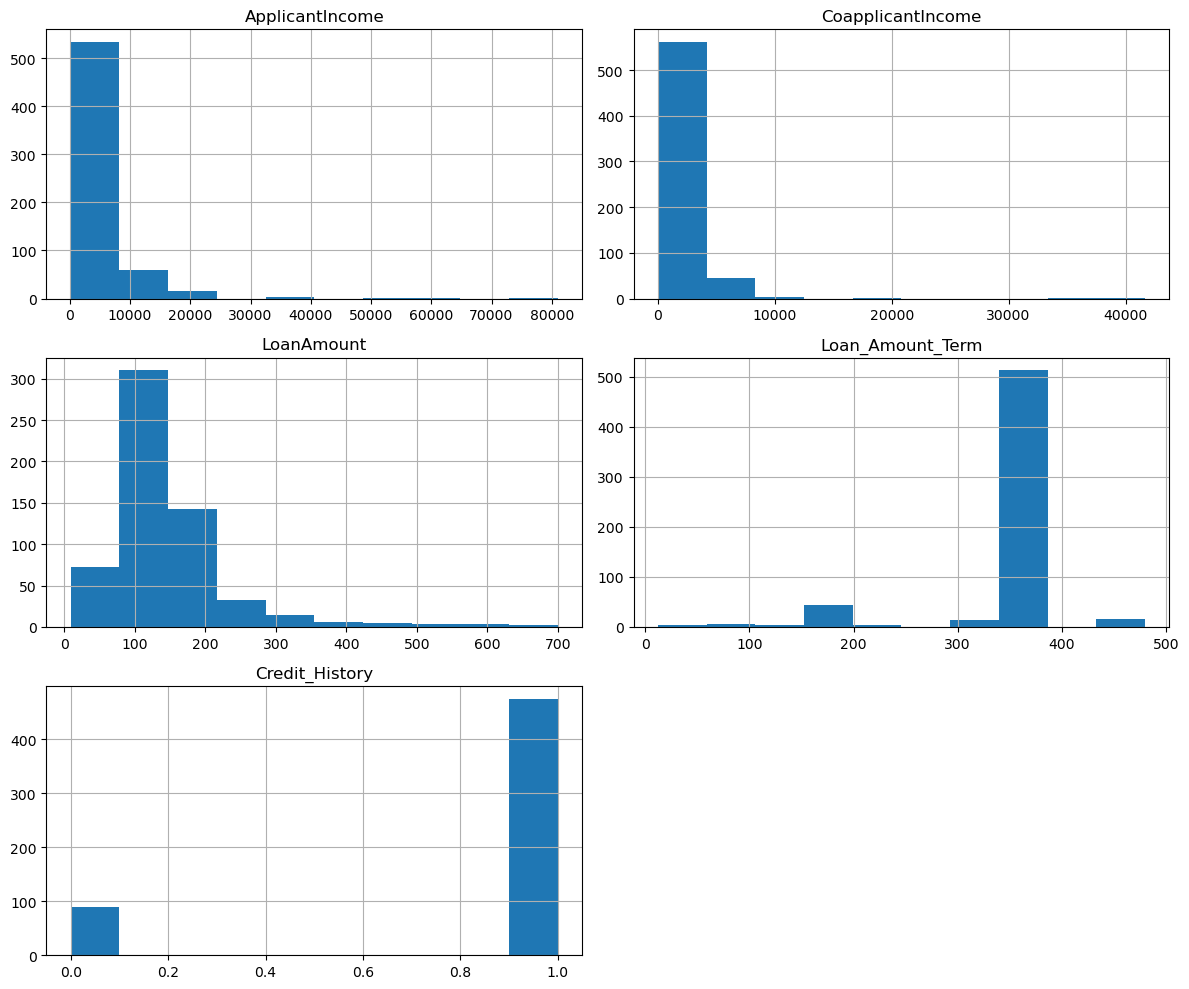

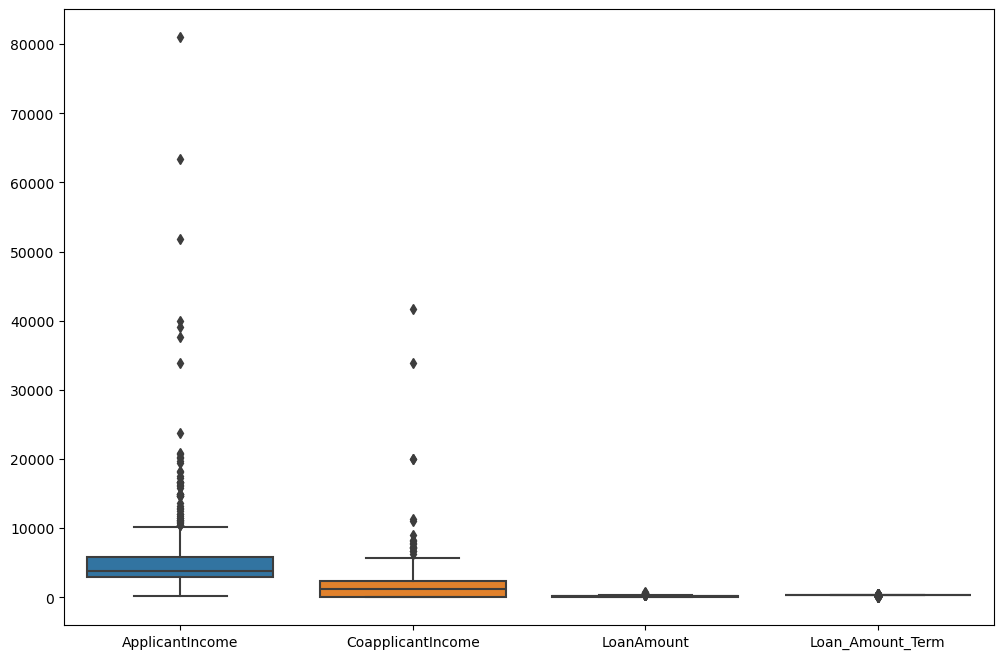

C:\Users\fatem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\fatem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\fatem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\fatem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

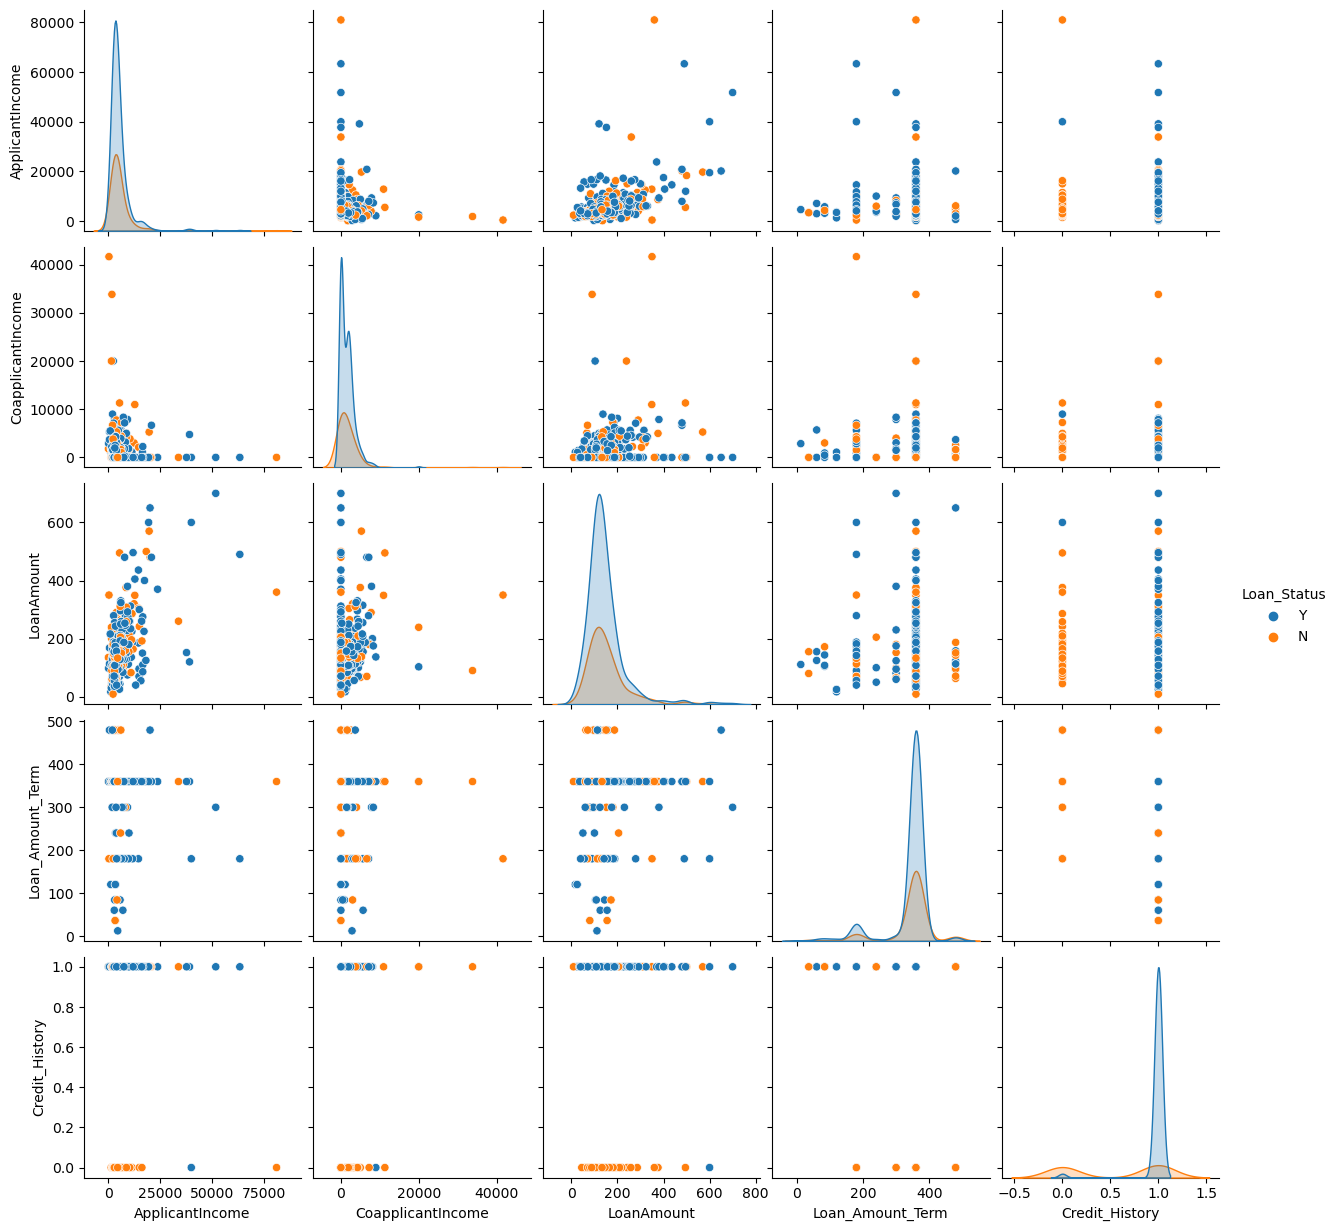

In [8]:
# Plot histograms
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Plot boxplots
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']])
plt.show()

# pairplot
sns.pairplot(df.drop(columns=['Loan_ID']), hue='Loan_Status')
plt.show()

# Data cleaning and preparation

In [9]:

# Check for missing values.
missing_values = df.isnull().sum()
# Print a summary of missing values.
print('Missing values per column:')
print(missing_values)


# Fill missing values for categorical columns with the mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill missing values for numerical columns with the mean
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)

# Convert Dependents column to numerical by replacing 3+ with 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

#feature engineering

# Creating an instance of OneHotEncoder with two output columns
encoder = ce.OneHotEncoder(cols=['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History'], use_cat_names=True)

# Encoding categorical columns
df = encoder.fit_transform(df)

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode 'Loan_Status' column
df['Loan_Status'] = label_encoder.fit_transform(df['Loan_Status'])


# Displaying the transformed DataFrame
print(df.head())
df.head(10)


# Verify if there are no more missing values
print(df.isnull().sum())


Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
    Loan_ID  Gender_Male  Gender_Female  Married_No  Married_Yes  Dependents  \
0  LP001002            1              0           1            0           0   
1  LP001003            1              0           0            1           1   
2  LP001005            1              0           0            1           0   
3  LP001006            1              0           0            1           0   
4  LP001008            1              0           1            0           0   

   Education_Graduate  Education_Not Graduate  Self_Employed_No  \
0                   1                       0                 1   
1                   1            

# Drop columns that won't be used for training

In [10]:
df.drop(['Loan_ID', 'Dependents','Property_Area'], axis=1, inplace=True)

# Correlations of each parameter with the target parameter

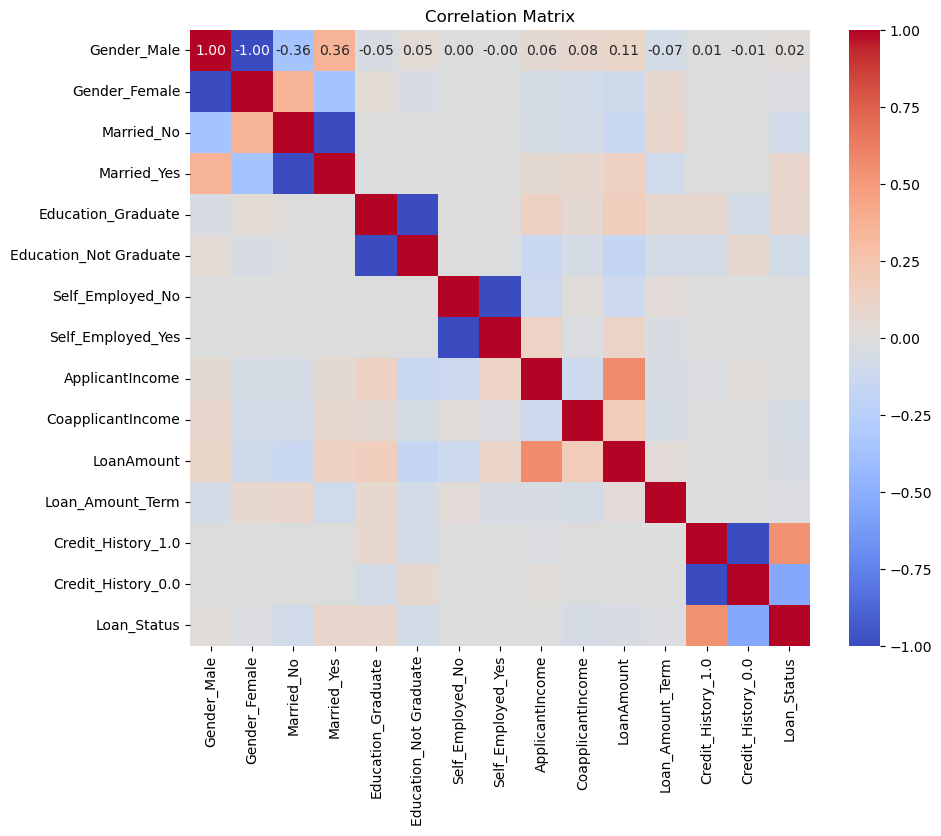

In [11]:
# Compute the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Train – Test Split

In [12]:

# Loan_Status is the dependent variable (value to be predicted), so it will be
# removed from the training data and put into a separate data frame for labels.
label_cols = ['Loan_Status']

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(df.drop(label_cols, axis=1),
                                                    df[label_cols],
                                                    random_state=1912)

# Compare number of rows and columns in original data to training and testing sets.
print(f'Original set:      {df.shape}')
print('------------------------------')
print(f'Training features: {X_train.shape}')
print(f'Testing features:  {X_test.shape}')
print(f'Training labels:   {y_train.shape}')
print(f'Testing labels:    {y_test.shape}')


Original set:      (614, 15)
------------------------------
Training features: (460, 14)
Testing features:  (154, 14)
Training labels:   (460, 1)
Testing labels:    (154, 1)


# Create a logistic regression model

In [13]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(solver = 'sag', C = 0.05, max_iter = 10000)
start = time()
log_reg.fit(X_train, np.ravel(y_train))
end = time()
train_time = (end - start) * 1000

# Score using the test data.
score = log_reg.score(X_test, y_test)

print('Logistic regression model took {:.2f} milliseconds to fit.'.format(train_time))
print('Score on test set: {:.0f}%'.format(score * 100))

Logistic regression model took 166.00 milliseconds to fit.
Score on test set: 67%


# Generate a confusion matrix

In [14]:
from sklearn.metrics import confusion_matrix

def c_matrix_graph(y, preds):
    '''Generates a confusion matrix based on model predictions.'''
    c_matrix = confusion_matrix(y, preds)
    
    ax = plt.subplot()

    sb.set(font_scale = 1.2)
    sb.heatmap(c_matrix, annot = True, fmt = 'g', ax = ax)
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Prediction', fontsize = 18);
    ax.set_ylabel('Actual', fontsize = 18);
    ax.xaxis.set_ticklabels(['Rejected (0)', 'Approved  (1)'], fontsize = 12, va = 'center');
    ax.yaxis.set_ticklabels(['Rejected (0)', 'Approved (1)'], fontsize = 12, va = 'center');
    
print('The confusion matrix graphing function has been defined.')

The confusion matrix graphing function has been defined.


# Compute accuracy, precision, recall, and F<sub>1</sub> score

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

def model_scores(y, preds):
    '''Generates various classification metrics based on model predictions.'''
    acc = accuracy_score(y, preds)
    print('Accuracy: {:.0f}%'.format(np.round(acc * 100)))
    
    precision = precision_score(y, preds)
    print('Precision: {:.0f}%'.format(np.round(precision * 100)))
    

    recall = recall_score(y, preds)
    print('Recall: {:.0f}%'.format(np.round(recall * 100)))
    
    f1 = f1_score(y, preds)
    print('F1: {:.0f}%'.format(np.round(f1 * 100)))
    
print('The function to compute scores has been defined.')

The function to compute scores has been defined.


# Generate a ROC curve and compute the AUC

In [16]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

def roc(y, pred_proba):
    '''Generates ROC curve based on model predictions.'''
   
    fpr, tpr, thresholds = roc_curve(y_test, initial_pred_proba[:, 1])
    plt.plot(fpr, tpr);
    plt.xlim([0.0, 1.0]);
    plt.ylim([0.0, 1.0]);
    plt.title('ROC Curve');
    plt.xlabel('False Positive Rate');
    plt.ylabel('True Positive Rate');
    plt.grid(True);
    
    auc = roc_auc_score(y, pred_proba)
    print('Area Under Curve: {:.2f}'.format(auc))
    
print('The function to generate a ROC curve and compute AUC has been defined.')

The function to generate a ROC curve and compute AUC has been defined.


# Generate a precision–recall curve and compute the average precision

In [17]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

def prc(y, pred_proba):
    '''Generates PRC based on model predictions.'''
    precision, recall, thresholds = precision_recall_curve(y, pred_proba)
    
    plt.plot(recall, precision);
    plt.xlim([0.0, 1.0]);
    plt.ylim([0.0, 1.0]);
    plt.title('Precision–Recall Curve');
    plt.xlabel('Recall');
    plt.ylabel('Precision');
    plt.grid(True);
    
    ap = average_precision_score(y, pred_proba)
    print('Average Precision: {:.2f}'.format(ap))
    
print('The function to generate a precision–recall curve and compute average precision has been defined.')

The function to generate a precision–recall curve and compute average precision has been defined.


# Evaluate the initial logistic regression model

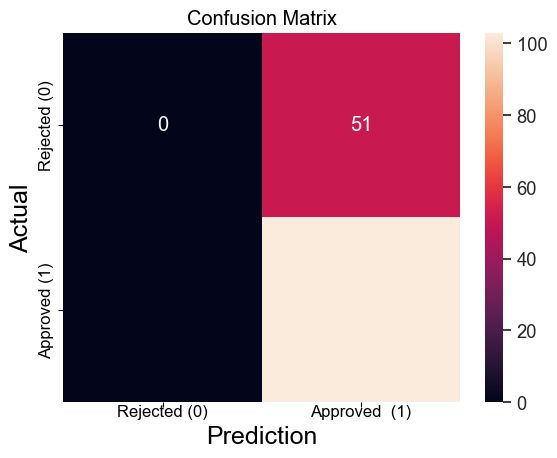

In [18]:
initial_preds = log_reg.predict(X_test)

c_matrix_graph(y_test, initial_preds)

In [19]:
model_scores(y_test, initial_preds)

Accuracy: 67%
Precision: 67%
Recall: 100%
F1: 80%


Area Under Curve: 0.45


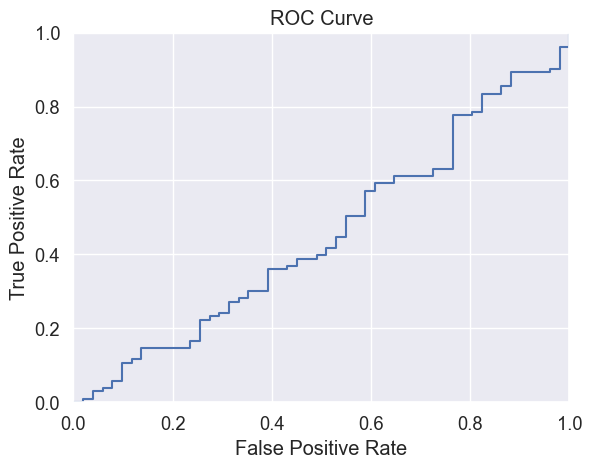

In [20]:
initial_pred_proba = log_reg.predict_proba(X_test)

roc(y_test, initial_pred_proba[:, 1])

Average Precision: 0.64


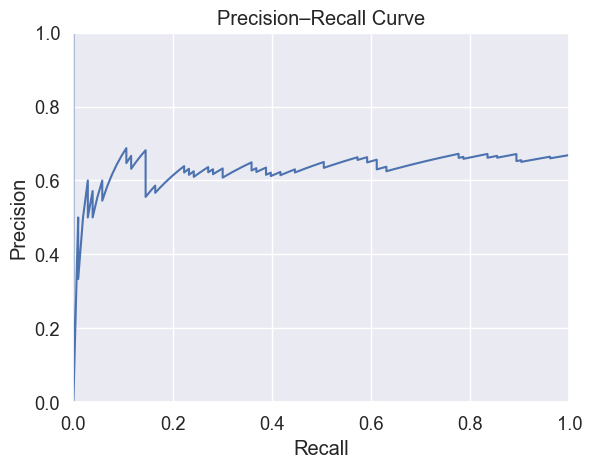

In [21]:
prc(y_test, initial_pred_proba[:, 1])

# Fit a logistic regression model using grid search with cross-validation

In [22]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define logistic regression model
log_reg = LogisticRegression(random_state=1912)

# Define the parameter grid for grid search
grid = [{'solver': ['liblinear', 'saga'],
         'penalty': ['l1', 'l2'],
         'C': [0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 100],
         'max_iter': [10000]}]

# Perform grid search with cross-validation
search = GridSearchCV(log_reg, param_grid=grid, scoring='f1', cv=5)
search.fit(X_train, np.ravel(y_train))

print("Best parameters:", search.best_params_)


Best parameters: {'C': 1, 'max_iter': 10000, 'penalty': 'l1', 'solver': 'liblinear'}


# Evaluate the optimized model


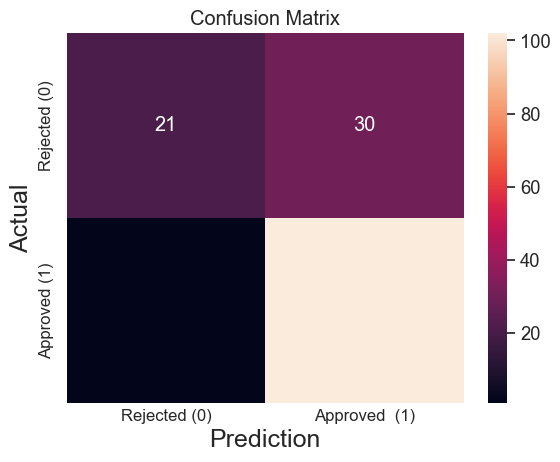

In [23]:
search_preds = search.predict(X_test)

c_matrix_graph(y_test, search_preds)

In [24]:
model_scores(y_test, search_preds)

Accuracy: 80%
Precision: 77%
Recall: 99%
F1: 87%


Area Under Curve: 0.77


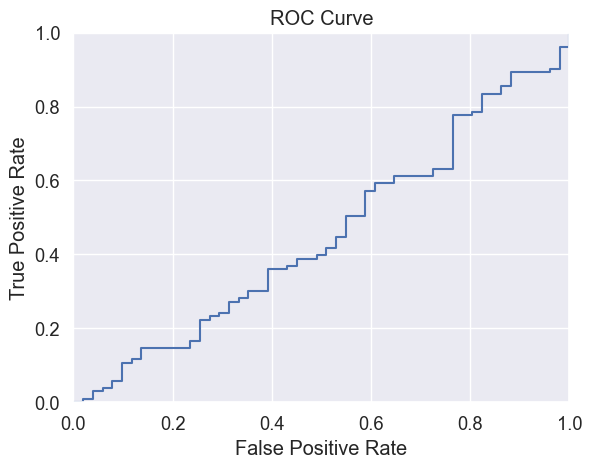

In [25]:
search_pred_proba = search.predict_proba(X_test)

roc(y_test, search_pred_proba[:, 1])

Average Precision: 0.83


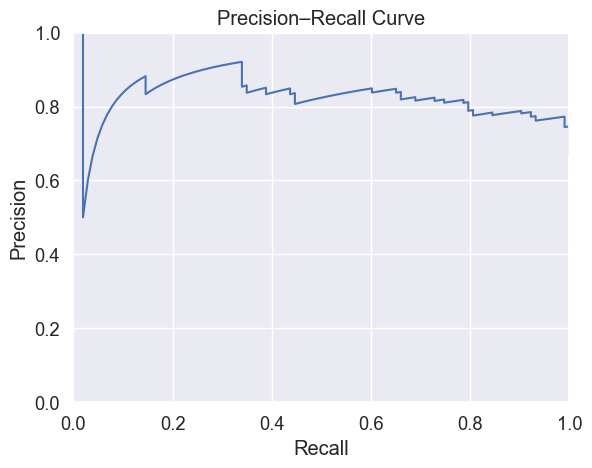

In [26]:
prc(y_test, search_pred_proba[:, 1])

# Create a *k*-nearest neighbor model

In [27]:
from math import sqrt

# Use bootstrapping to find ideal k value.
k_num = round(sqrt(X_train.shape[0]))

# Make k odd if it is even.
if k_num % 2 == 0:
    k_num += 1

from sklearn.neighbors import KNeighborsClassifier

# Train model.
knn = KNeighborsClassifier(n_neighbors = k_num) 
start = time()
knn.fit(X_train, np.ravel(y_train))  
end = time()
train_time = (end - start) * 1000

# Score using the test data.
score = knn.score(X_test, y_test)

print('Value of k: {}'.format(k_num))
print('KNN model took {:.2f} milliseconds to fit.'.format(train_time))
print('Score on validation set: {:.0f}%'.format(score * 100))

Value of k: 21
KNN model took 5.01 milliseconds to fit.
Score on validation set: 67%


# Evaluate the K-NN model

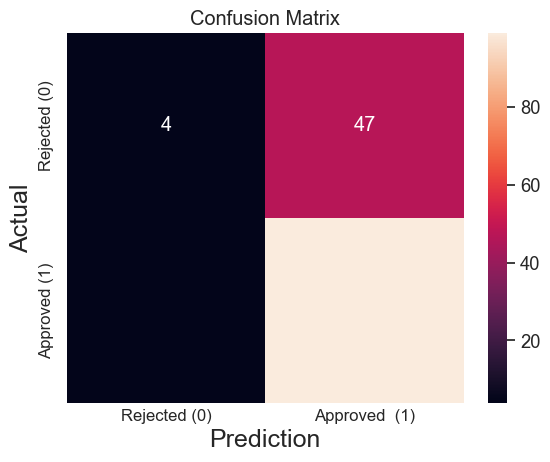

In [28]:
initial_preds = knn.predict(X_test)

c_matrix_graph(y_test, initial_preds)

In [29]:
model_scores(y_test, initial_preds)

Accuracy: 67%
Precision: 68%
Recall: 96%
F1: 80%


Area Under Curve: 0.53


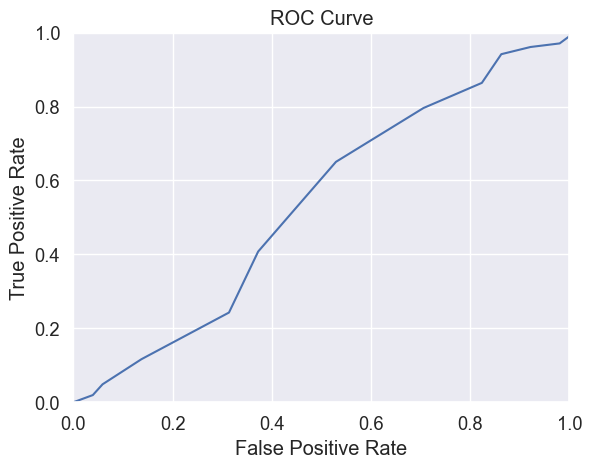

In [30]:
initial_pred_proba = knn.predict_proba(X_test)

roc(y_test, initial_pred_proba[:, 1])

Average Precision: 0.67


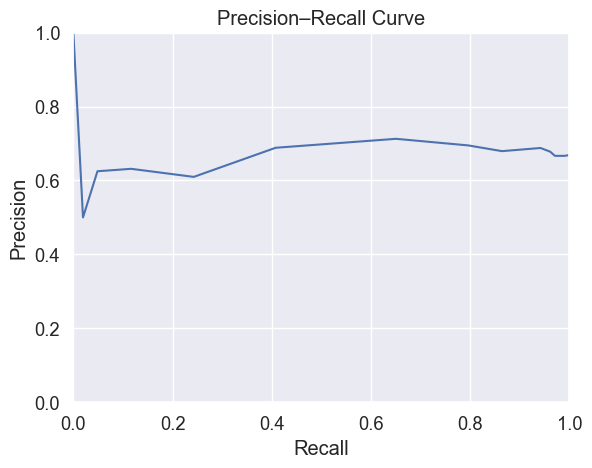

In [31]:
prc(y_test, initial_pred_proba[:, 1])

# Fit a K-NN model using grid search with cross-validation

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Define KNN model
knn = KNeighborsClassifier()

# Define the parameter grid for grid search
grid = {'n_neighbors': [3, 5, 7, 9, 11],  
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']}

# Fit KNN model with training data
knn.fit(X_train, np.ravel(y_train))

# Perform grid search with cross-validation
search = GridSearchCV(knn, param_grid=grid, scoring='f1', cv=5)
search.fit(X_train, np.ravel(y_train))

print("Best parameters:", search.best_params_)



Best parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}


# Evaluate the K-NN model

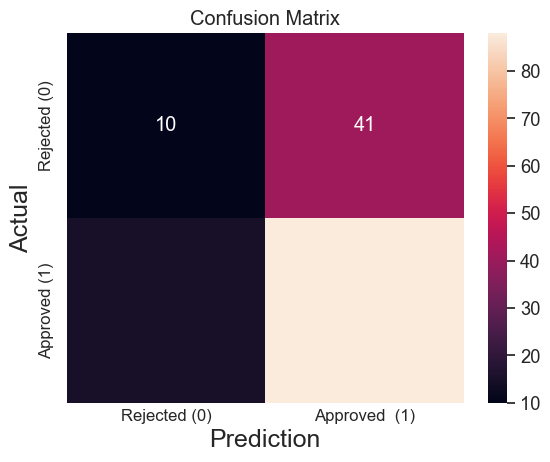

In [33]:
initial_preds = knn.predict(X_test)

c_matrix_graph(y_test, initial_preds)

In [34]:
model_scores(y_test, initial_preds)

Accuracy: 64%
Precision: 68%
Recall: 85%
F1: 76%


Area Under Curve: 0.50


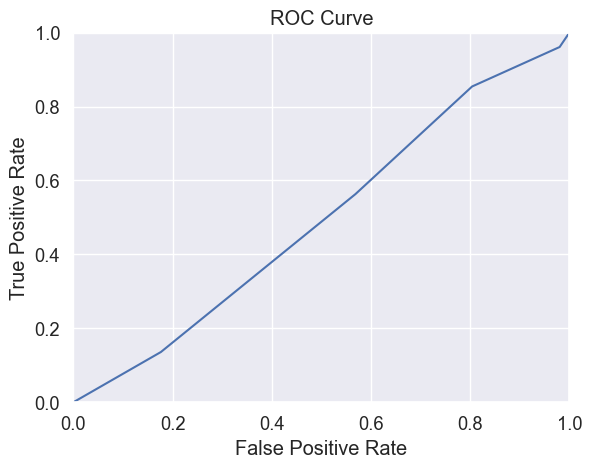

In [35]:
initial_pred_proba = knn.predict_proba(X_test)

roc(y_test, initial_pred_proba[:, 1])

Average Precision: 0.66


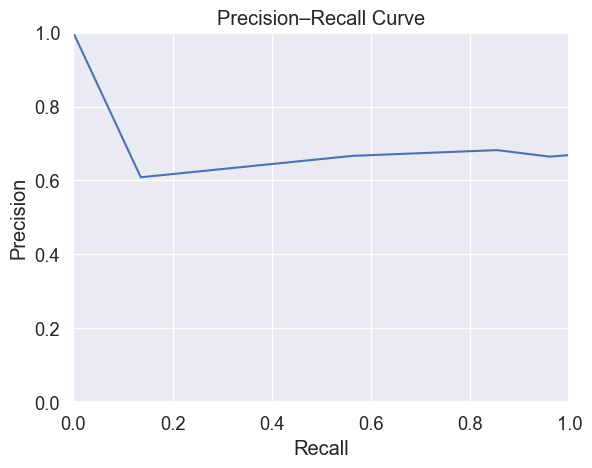

In [36]:
prc(y_test, initial_pred_proba[:, 1])

# SVM

from sklearn.svm import SVC
# Evaluate an SVM model using a holdout test set
svm = SVC(kernel = 'linear', C = 100, random_state = 1936)
svm.fit(X_train, np.ravel(y_train))

# Score using the test data.
score = svm.score(X_test, y_test)

print('Accuracy: {:.0f}%'.format(score * 100))

# Evaluate the SVM model

In [37]:
initial_preds = svm.predict(X_test)

c_matrix_graph(y_test, initial_preds)

NameError: name 'svm' is not defined

In [38]:
model_scores(y_test, initial_preds)

Accuracy: 64%
Precision: 68%
Recall: 85%
F1: 76%


initial_pred_proba = svm.predict_proba(X_test)

roc(y_test, initial_pred_proba[:, 1])

Average Precision: 0.66


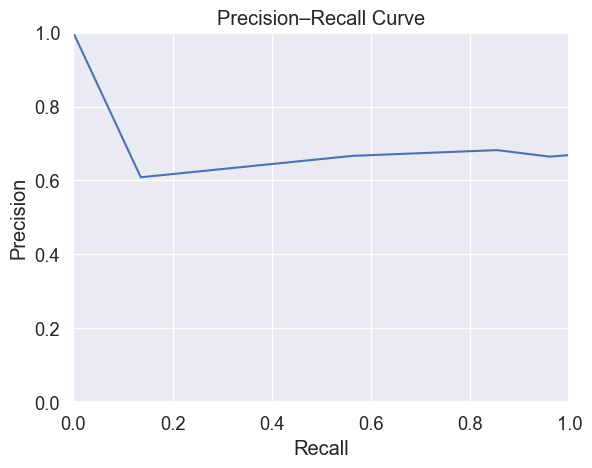

In [39]:
prc(y_test, initial_pred_proba[:, 1])

# Optimize the SVM model with grid search and cross-validation


from sklearn.model_selection import GridSearchCV

svm = SVC(gamma = 'auto', random_state = 1936)

grid = [{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
         'C': [0.01, 0.1, 1, 5, 10, 25, 50, 100]}]

search = GridSearchCV(svm, param_grid = grid, scoring = 'accuracy', cv = 5)
search.fit(X_train, np.ravel(y_train));

print(search.best_params_)

# Score using the test data.


score = search.score(X_test, y_test)

print('Accuracy: {:.0f}%'.format(score * 100))

# Decision Trees and Random Forests

# Bin

In [40]:
print('Shortest Loan Term:  {} months'.format(df['Loan_Amount_Term'].min()))
print('Longest Loan Term:   {} months'.format(df['Loan_Amount_Term'].max()))

print('Lowest Loan Amount:  {}'.format(df['LoanAmount'].min()))
print('Highest Loan Amount: {}'.format(df['LoanAmount'].max()))


Shortest Loan Term:  12.0 months
Longest Loan Term:   480.0 months
Lowest Loan Amount:  9.0
Highest Loan Amount: 700.0


In [41]:
# Define LoanAmount bins and labels
loan_amount_bins = [0, 100, 200, 300, 400]
loan_amount_labels = ['0–100', '101–200', '201–300', '301–400']

loan_amount_group = pd.cut(df['LoanAmount'], bins=loan_amount_bins, labels=loan_amount_labels, right=False)
df['LoanAmount_grp'] = loan_amount_group

loan_amount_encoded = df['LoanAmount_grp'].cat.codes
df['LoanAmount_code'] = loan_amount_encoded

# Define Loan_Amount_Term bins and labels
loan_term_bins = [0, 120, 240, 360, 480]
loan_term_labels = ['0–10', '11–20', '21–30', '31–40']

loan_term_group = pd.cut(df['Loan_Amount_Term'], bins=loan_term_bins, labels=loan_term_labels, right=False)
df['Loan_Amount_Term_grp'] = loan_term_group

loan_term_encoded = df['Loan_Amount_Term_grp'].cat.codes
df['Loan_Amount_Term_code'] = loan_term_encoded

# Display the updated DataFrame
df.head()

,Gender_Male,Gender_Female,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History_1.0,Credit_History_0.0,Loan_Status,LoanAmount_grp,LoanAmount_code,Loan_Amount_Term_grp,Loan_Amount_Term_code
0,1,0,1,0,1,0,1,0,5849,0.0,146.412162,360.0,1,0,1,101–200,1,31–40,3
1,1,0,0,1,1,0,1,0,4583,1508.0,128.000000,360.0,1,0,0,101–200,1,31–40,3
2,1,0,0,1,1,0,0,1,3000,0.0,66.000000,360.0,1,0,1,0–100,0,31–40,3
3,1,0,0,1,0,1,1,0,2583,2358.0,120.000000,360.0,1,0,1,101–200,1,31–40,3
4,1,0,1,0,1,0,1,0,6000,0.0,141.000000,360.0,1,0,1,101–200,1,31–40,3


# Create a basic decision tree model

In [42]:

from sklearn.tree import DecisionTreeClassifier

first_tree = DecisionTreeClassifier(random_state = 1912)
start = time()
first_tree.fit(X_train, np.ravel(y_train))
end = time()
train_time = (end - start) * 1000

# Get predictions on test data.
initial_preds = first_tree.predict(X_test)

# Score using the test data.
score = first_tree.score(X_test, y_test)

print('Decision tree model took {:.2f} milliseconds to fit.'.format(train_time))
print('Accuracy: {:.0f}%'.format(score * 100))

Decision tree model took 2.98 milliseconds to fit.
Accuracy: 71%


# Visualize the decision tree structure

In [43]:

from sklearn import tree

def plot_tree(model):
    fig = plt.figure(figsize = (25, 20))
    tree.plot_tree(model,
                   feature_names = list(X_train.columns),  
                   class_names = ['Approved ', 'Rejected'],
                   filled = True)
    
print('A function to plot the decision tree structure has been defined.')

A function to plot the decision tree structure has been defined.


# Confusion Matrix for decision tree

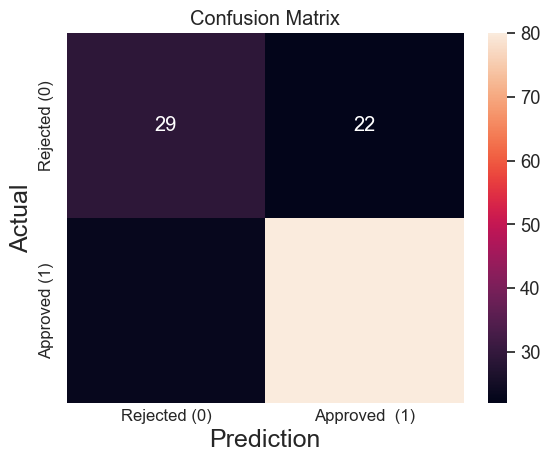

In [44]:

initial_preds = first_tree.predict(X_test)

c_matrix_graph(y_test, initial_preds)

# Evaluate the initial decision tree model

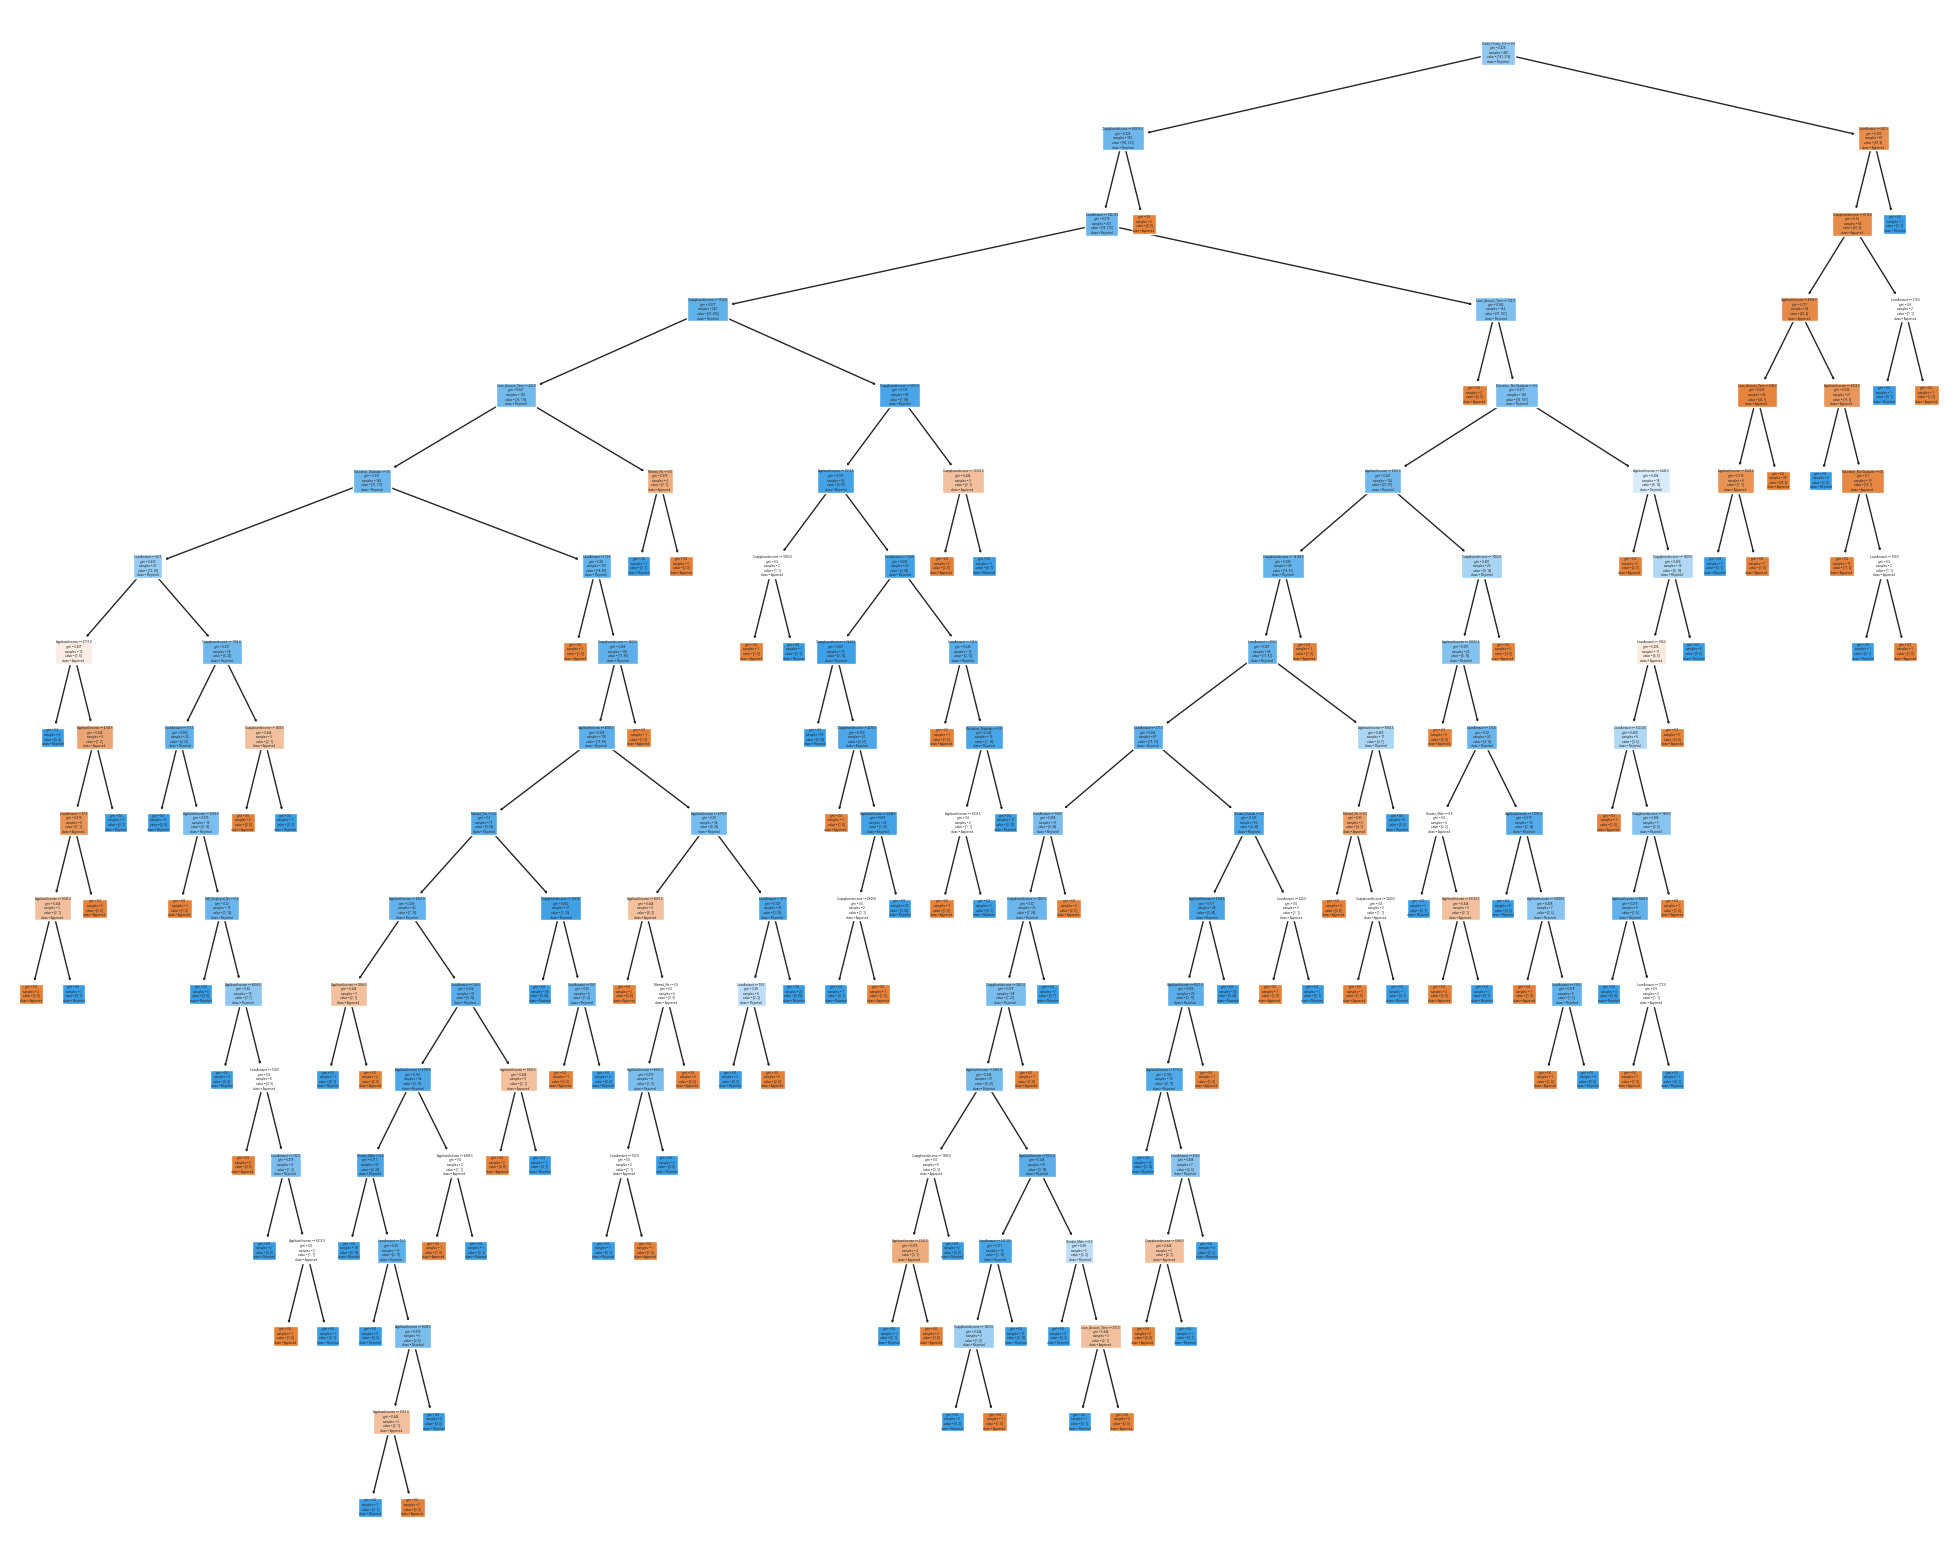

In [45]:
plot_tree(first_tree)

In [46]:
model_scores(y_test, initial_preds)

Accuracy: 71%
Precision: 78%
Recall: 78%
F1: 78%


Area Under Curve: 0.67


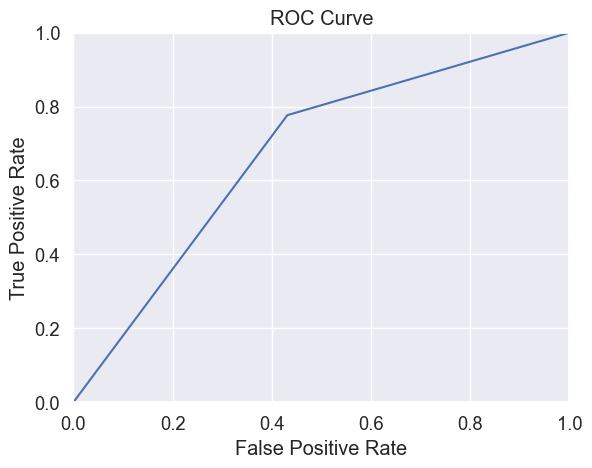

In [47]:
initial_pred_proba = first_tree.predict_proba(X_test)

roc(y_test, initial_pred_proba[:, 1])

Average Precision: 0.76


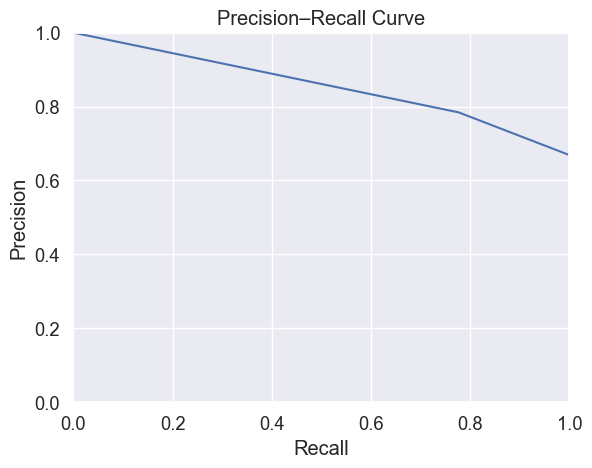

In [48]:
prc(y_test, initial_pred_proba[:, 1])

# Performing pre-pruning on the decision tree

In [49]:
pruned_tree = DecisionTreeClassifier(max_depth = 3, random_state = 1912)
start = time()
pruned_tree.fit(X_train, np.ravel(y_train))
end = time()
train_time = (end - start) * 1000

pruned_preds = pruned_tree.predict(X_test)

# Score using the test data.
score = pruned_tree.score(X_test, y_test)

print('Decision tree model took {:.2f} milliseconds to fit.'.format(train_time))
print('Accuracy: {:.0f}%'.format(score * 100))

Decision tree model took 5.00 milliseconds to fit.
Accuracy: 80%


# Evaluate the pruned decision tree model

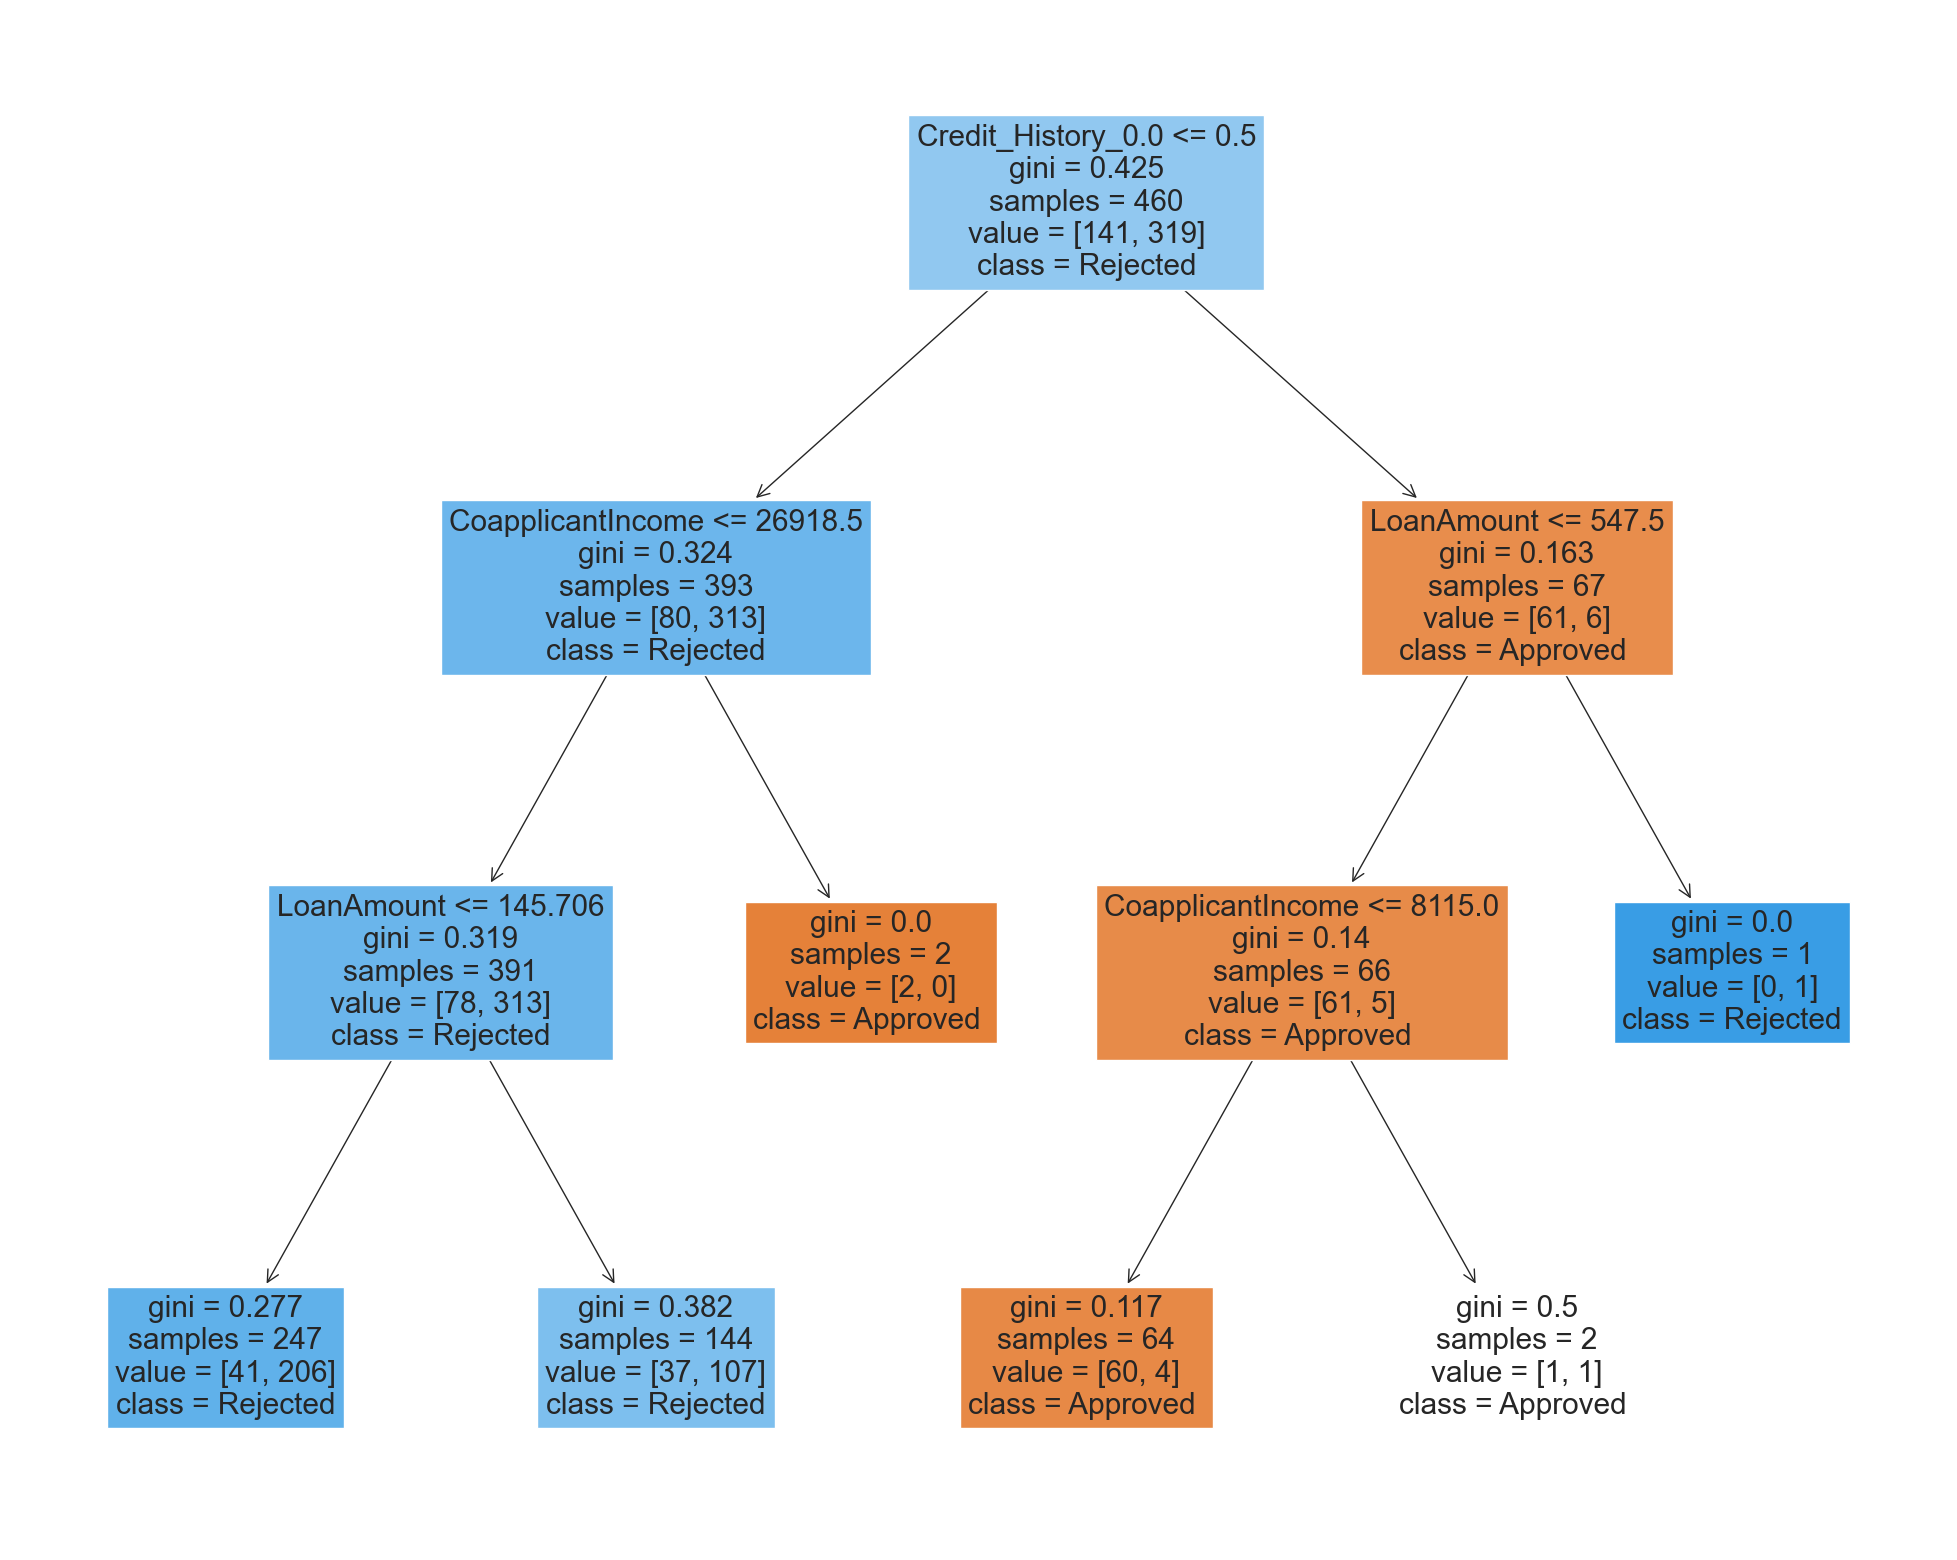

In [50]:
plot_tree(pruned_tree)

In [51]:
model_scores(y_test, pruned_preds)

Accuracy: 80%
Precision: 77%
Recall: 99%
F1: 87%


Area Under Curve: 0.75


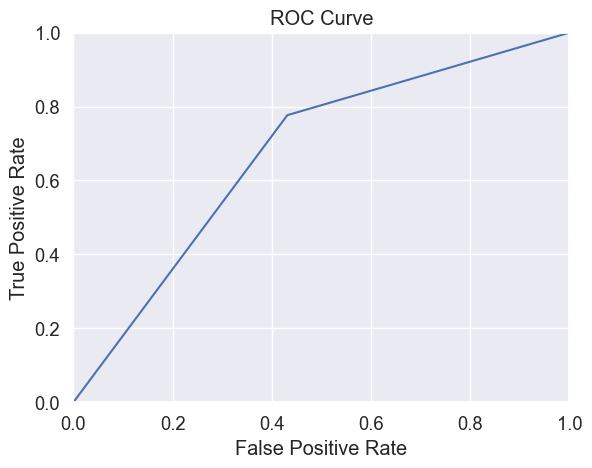

In [52]:
pruned_pred_proba = pruned_tree.predict_proba(X_test)

roc(y_test, pruned_pred_proba[:, 1])

Average Precision: 0.80


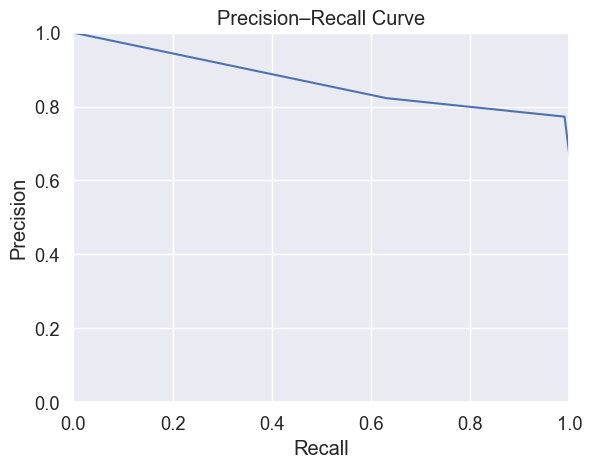

In [53]:
prc(y_test, pruned_pred_proba[:, 1])

In [54]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for grid search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=first_tree, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


# Evaluate after grid search

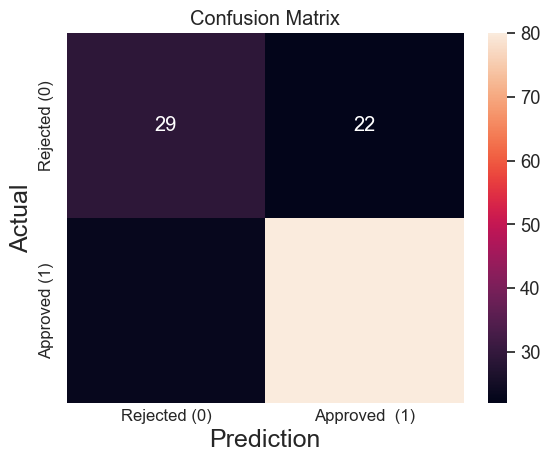

In [55]:
initial_preds = first_tree.predict(X_test)

c_matrix_graph(y_test, initial_preds)

In [56]:
model_scores(y_test, pruned_preds)

Accuracy: 80%
Precision: 77%
Recall: 99%
F1: 87%


Area Under Curve: 0.75


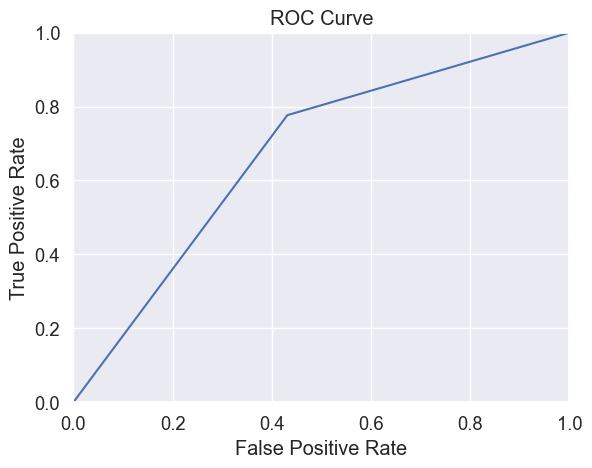

In [57]:
pruned_pred_proba = pruned_tree.predict_proba(X_test)

roc(y_test, pruned_pred_proba[:, 1])

Average Precision: 0.80


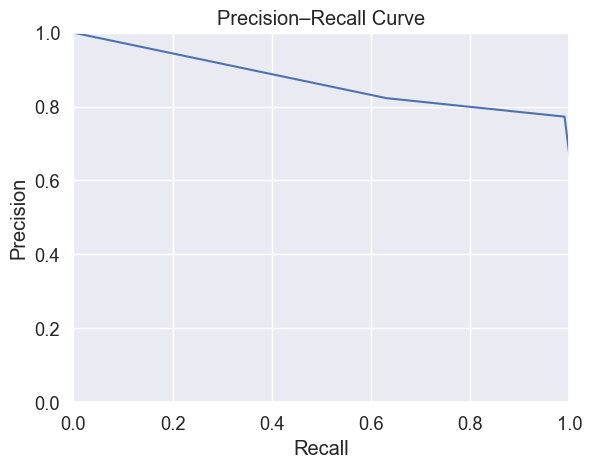

In [58]:
prc(y_test, pruned_pred_proba[:, 1])

# Create a random forest model

In [59]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators = 100,
                                max_depth = 4,
                                bootstrap = True,
                                oob_score = True,
                                random_state = 1912)

start = time()
forest.fit(X_train, np.ravel(y_train))
end = time()
train_time = (end - start) * 1000

forest_preds = forest.predict(X_test)

# Score using the test data.
score = forest.score(X_test, y_test)


print('Random forest model took {:.2f} milliseconds to fit.'.format(train_time))
print('Accuracy: {:.0f}%'.format(score * 100))

Random forest model took 201.40 milliseconds to fit.
Accuracy: 80%


# Examine a couple of trees in the forest


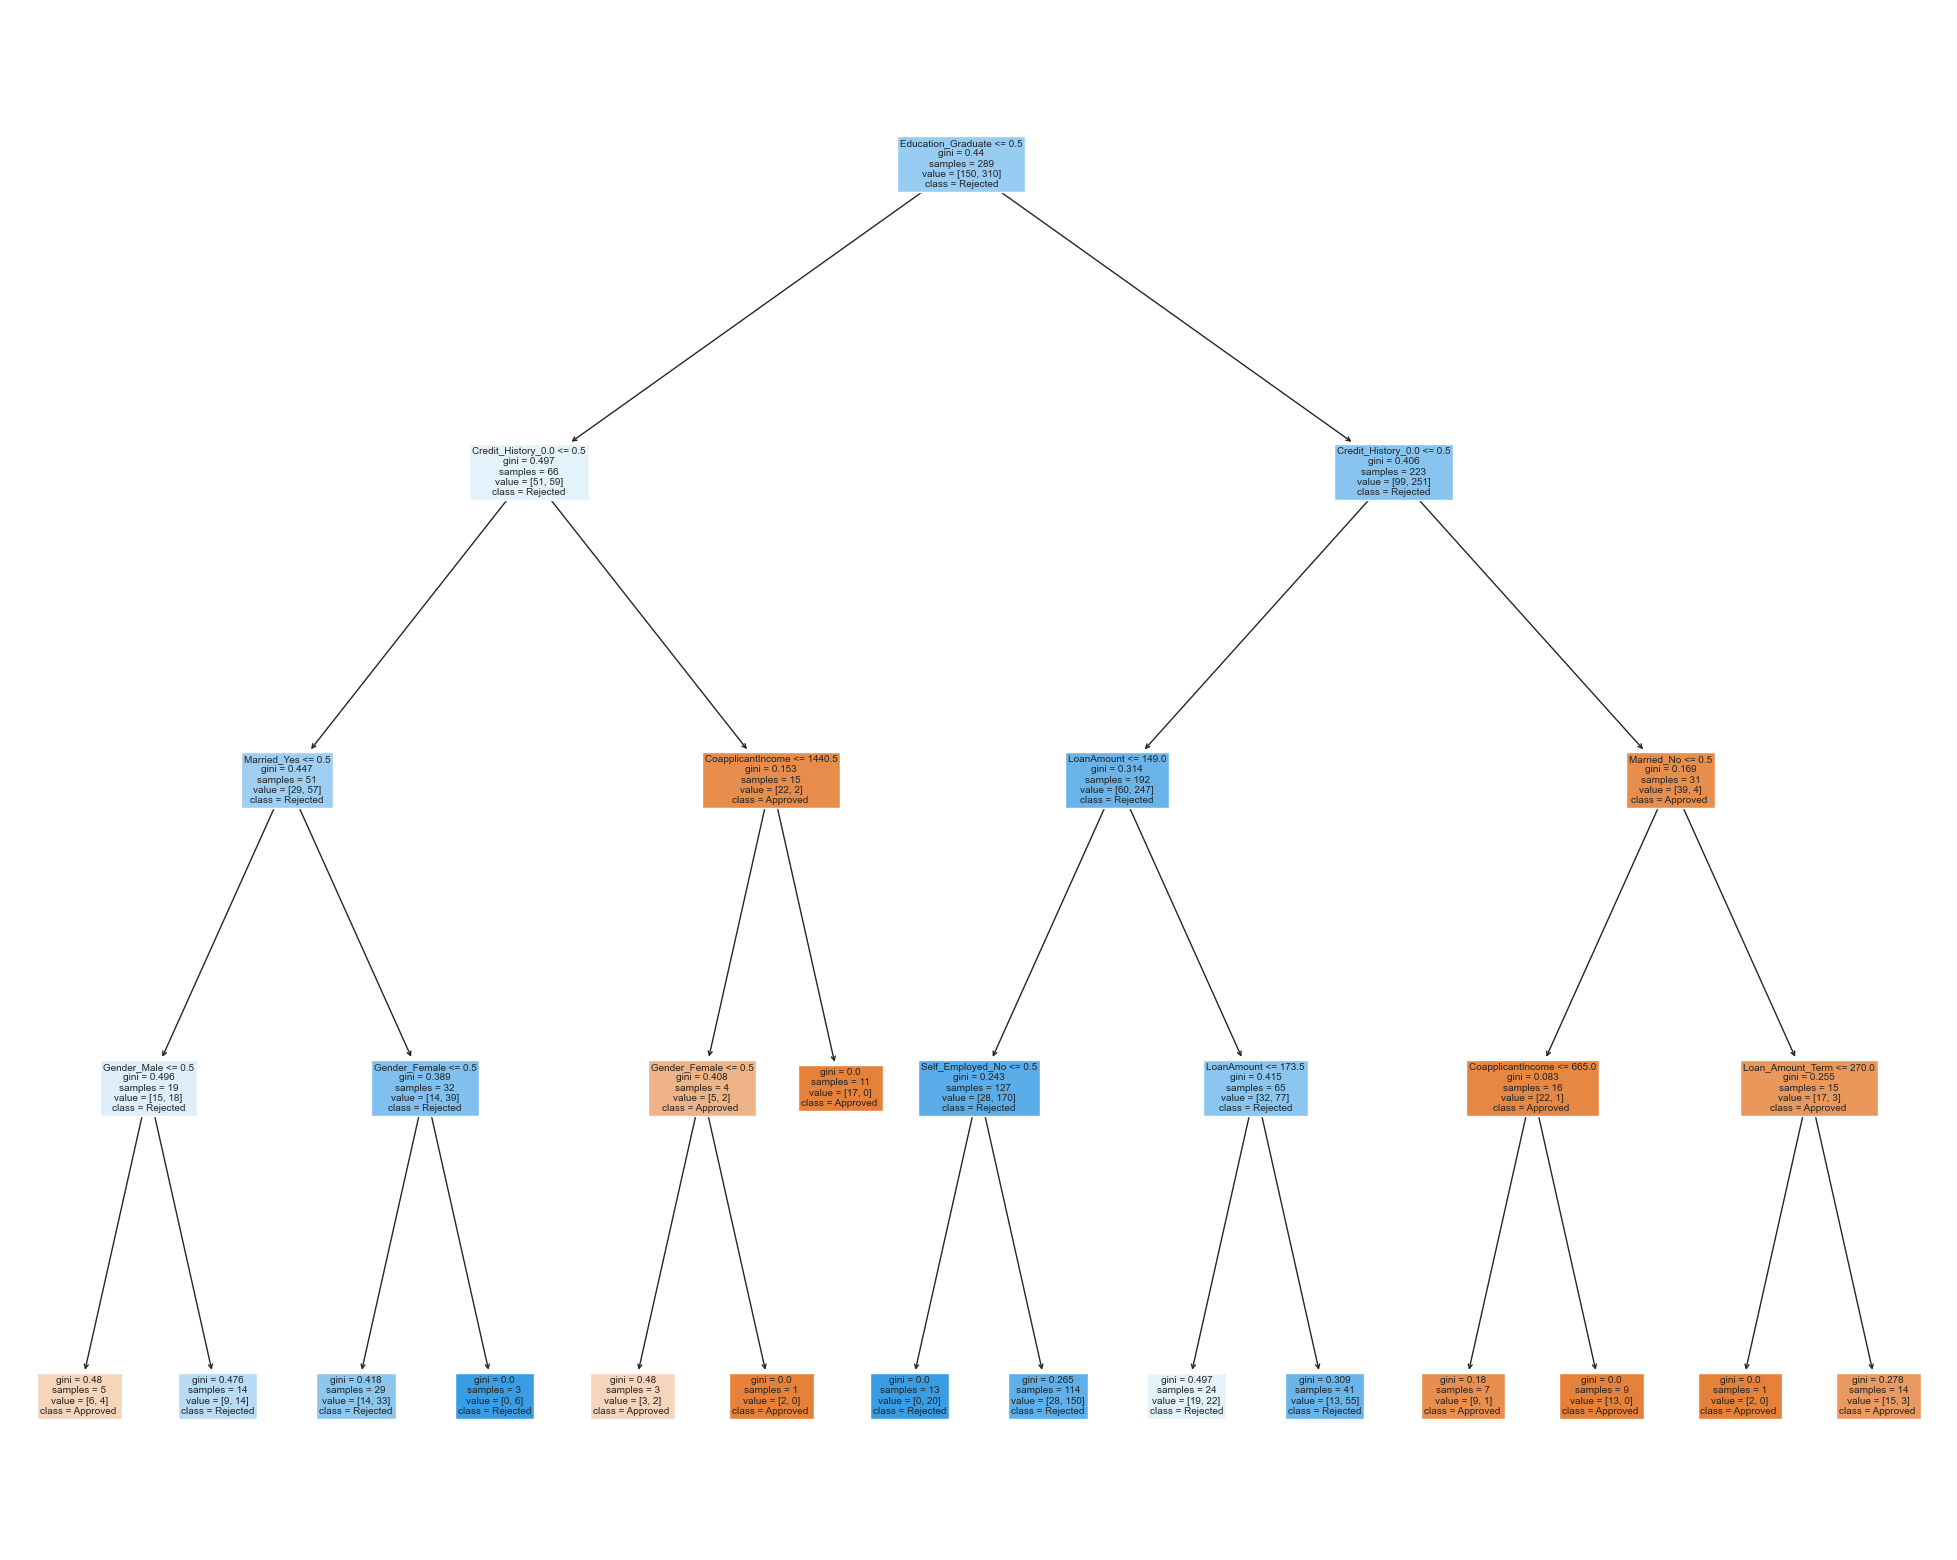

In [60]:
plot_tree(forest.estimators_[0])

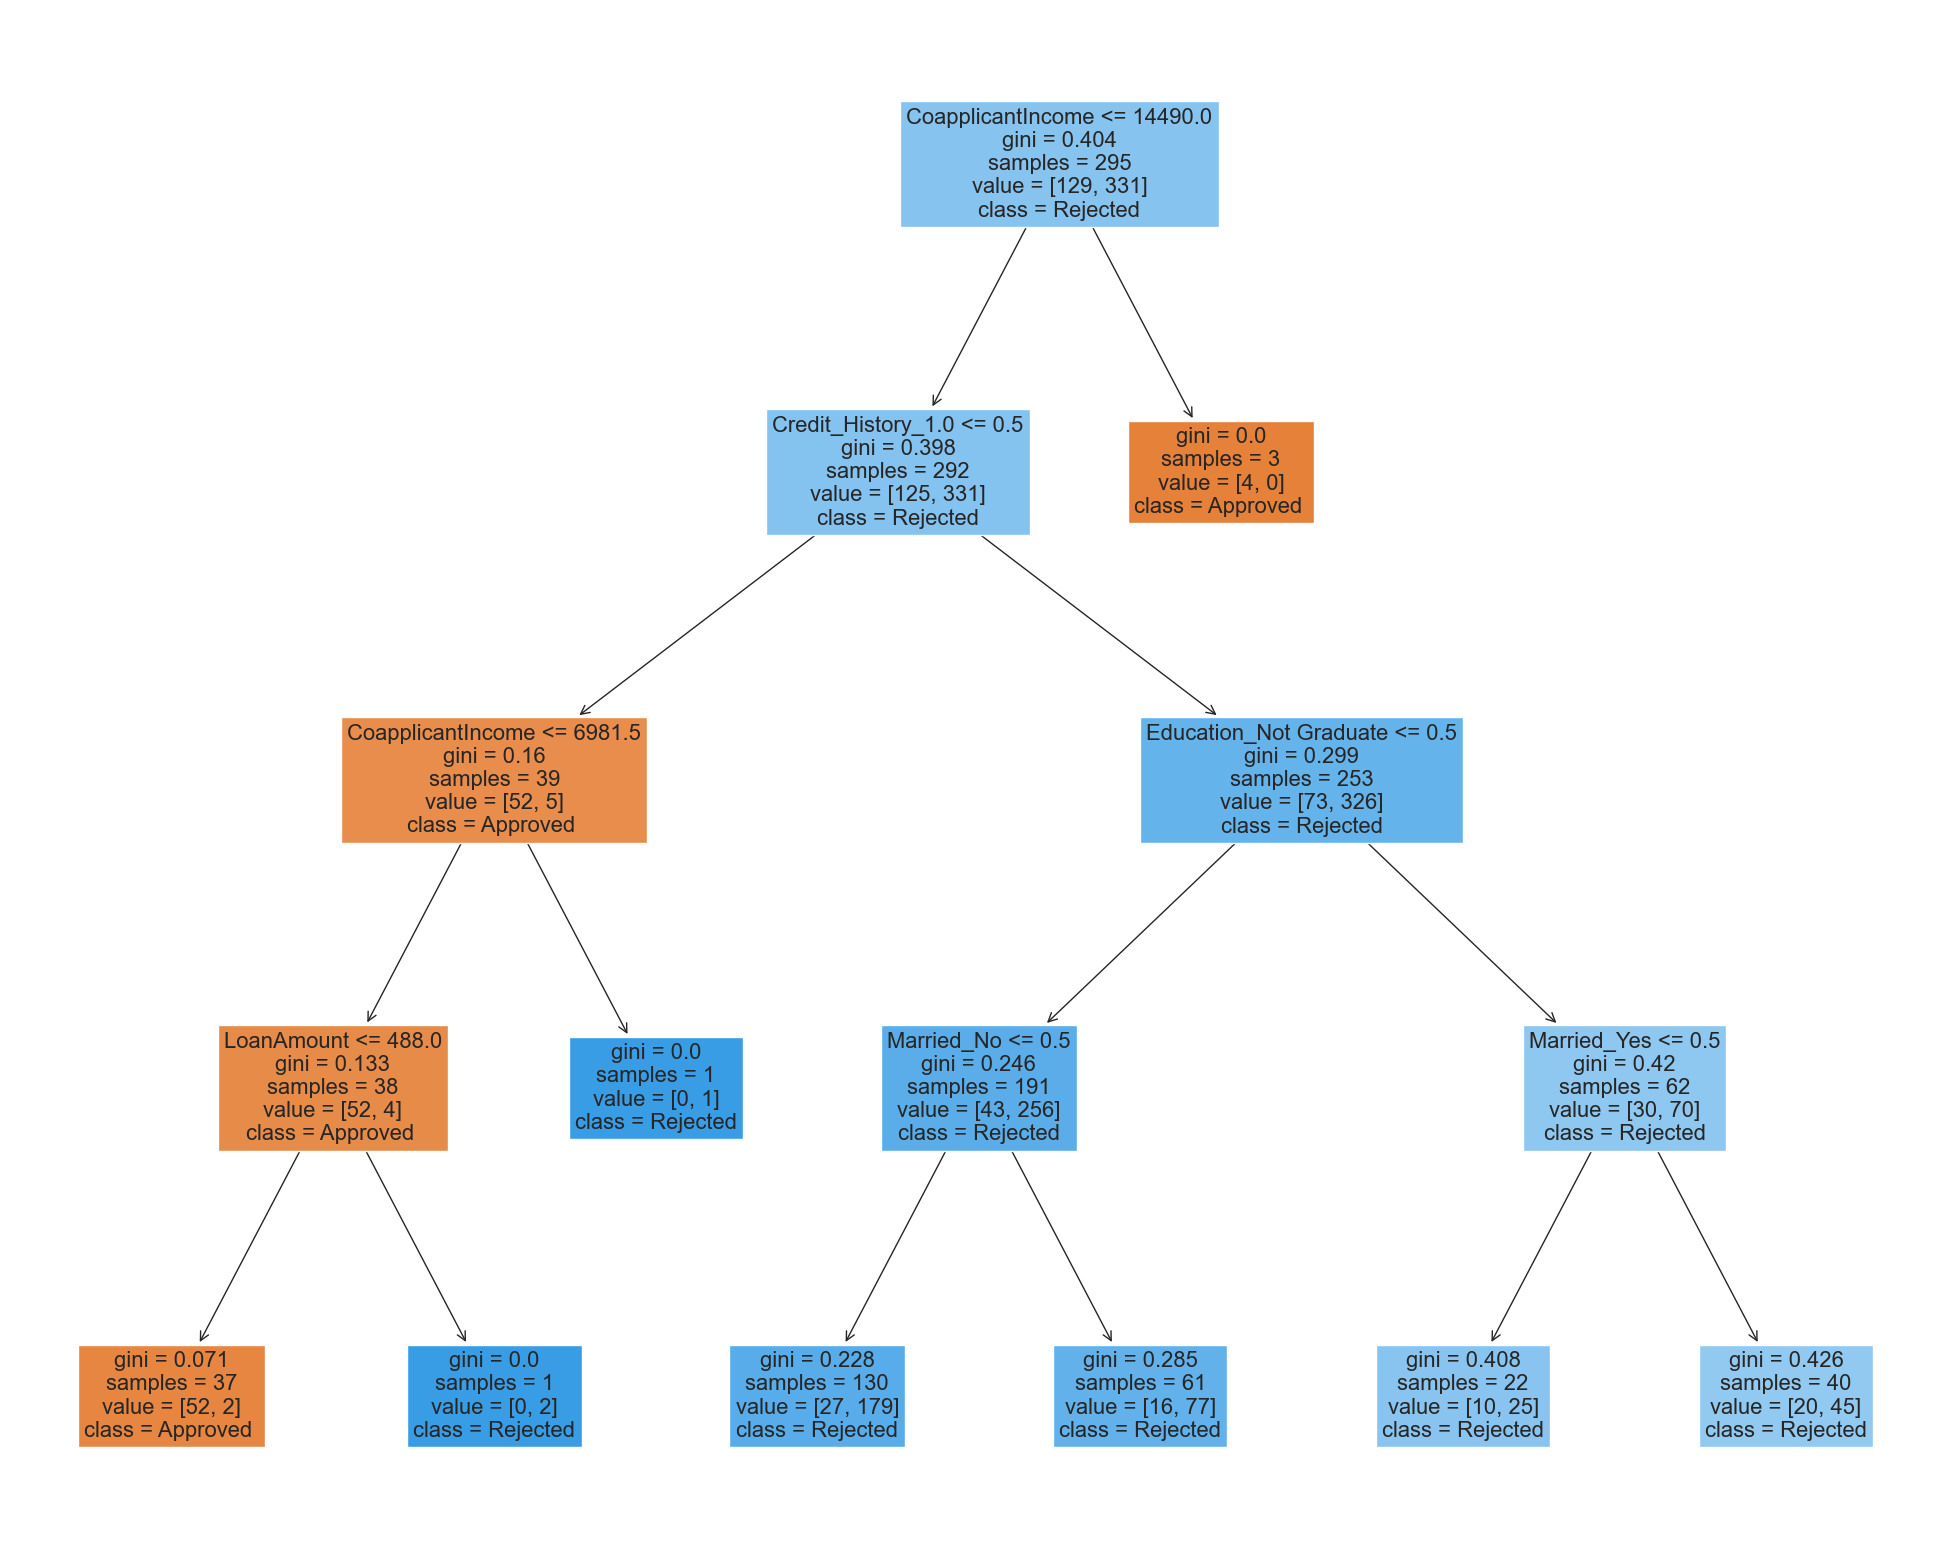

In [61]:
plot_tree(forest.estimators_[1])

# Evaluate the random forest model

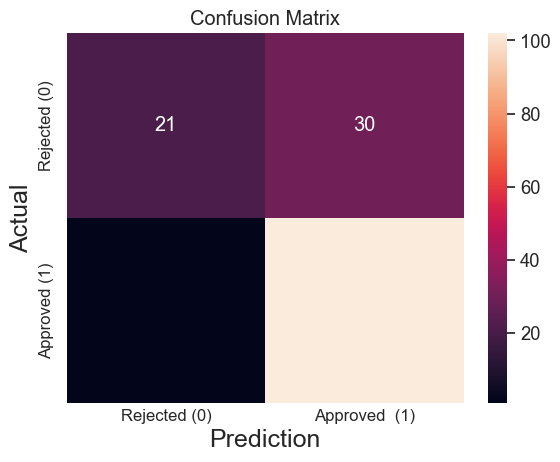

In [62]:
initial_preds = forest.predict(X_test)

c_matrix_graph(y_test, initial_preds)

In [63]:
model_scores(y_test, forest_preds)

Accuracy: 80%
Precision: 77%
Recall: 99%
F1: 87%


Area Under Curve: 0.76


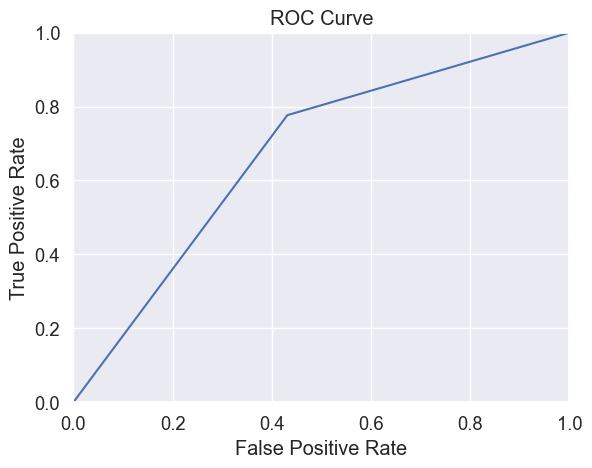

In [64]:
forest_pred_proba = forest.predict_proba(X_test)

roc(y_test, forest_pred_proba[:, 1])

Average Precision: 0.84


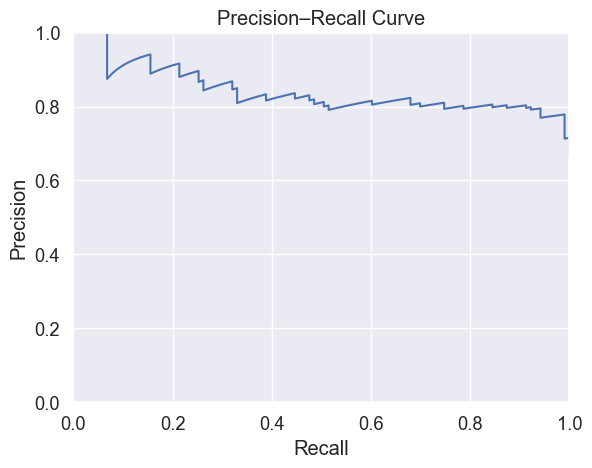

In [65]:
prc(y_test, forest_pred_proba[:, 1])

# Generate the out-of-bag error and decision function

In [66]:
oob_error = 1 - forest.oob_score_
print('Out-of-bag error: {}'.format(round(oob_error, 3)))

Out-of-bag error: 0.187


In [67]:
forest.oob_decision_function_

array([[0.25378221, 0.74621779],
       [0.74496421, 0.25503579],
       [0.15315034, 0.84684966],
       [0.26801623, 0.73198377],
       [0.18980775, 0.81019225],
       [0.32018621, 0.67981379],
       [0.21637762, 0.78362238],
       [0.17845181, 0.82154819],
       [0.18149819, 0.81850181],
       [0.22836779, 0.77163221],
       [0.22324877, 0.77675123],
       [0.19244926, 0.80755074],
       [0.78872844, 0.21127156],
       [0.1632479 , 0.8367521 ],
       [0.23525541, 0.76474459],
       [0.15792055, 0.84207945],
       [0.69876925, 0.30123075],
       [0.35400185, 0.64599815],
       [0.8659795 , 0.1340205 ],
       [0.16478871, 0.83521129],
       [0.22653552, 0.77346448],
       [0.17384846, 0.82615154],
       [0.16796368, 0.83203632],
       [0.26191412, 0.73808588],
       [0.80784859, 0.19215141],
       [0.20323686, 0.79676314],
       [0.28797703, 0.71202297],
       [0.21204981, 0.78795019],
       [0.77203657, 0.22796343],
       [0.17402199, 0.82597801],
       [0.

# Drop the unimportant features for a new round of training

In [68]:

drop_feats = ['Gender_Male', 'Self_Employed_No', 'Self_Employed_Yes','Gender_Female'] 

X_train_reduce = X_train.drop(drop_feats, axis=1)
X_test_reduce = X_test.drop(drop_feats, axis=1)

X_train_reduce.head()

X_train_reduce = X_train.drop(drop_feats, axis = 1)
X_test_reduce = X_test.drop(drop_feats, axis = 1)

X_train_reduce.head()

,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History_1.0,Credit_History_0.0
535,1,0,0,1,2550,2042.0,126.000000,360.0,1,0
300,0,1,0,1,1800,2934.0,93.000000,360.0,0,1
437,0,1,1,0,2213,1125.0,146.412162,360.0,1,0
172,0,1,0,1,3522,0.0,81.000000,180.0,1,0
345,0,1,1,0,2499,2458.0,160.000000,360.0,1,0


In [69]:
forest = RandomForestClassifier(n_estimators=200,  # Increase number of trees
                                 max_depth=6,       # Increase maximum depth
                                 min_samples_split=5, # Adjust minimum samples required to split
                                 min_samples_leaf=2,  # Adjust minimum samples required at a leaf node
                                 max_features='sqrt', # Adjust maximum number of features to consider
                                 bootstrap=True,     # Use bootstrap sampling
                                 oob_score=True,     # Calculate out-of-bag score
                                 random_state=1912)


# Train a new random forest model on the dataset with reduced dimensionality

In [70]:
forest = RandomForestClassifier(n_estimators = 100,
                                max_depth = 4,
                                bootstrap = True,
                                oob_score = True,
                                random_state = 1912)

start = time()
forest.fit(X_train_reduce, np.ravel(y_train))
end = time()
train_time = (end - start) * 1000

forest_preds = forest.predict(X_test_reduce)

# Score using the test data.
score = forest.score(X_test_reduce, y_test)

print('Random forest model took {:.2f} milliseconds to fit.'.format(train_time))
print('Accuracy: {:.0f}%'.format(score * 100))

Random forest model took 190.16 milliseconds to fit.
Accuracy: 80%


# Evaluate the new random forest model

In [71]:
model_scores(y_test, forest_preds)

Accuracy: 80%
Precision: 77%
Recall: 99%
F1: 87%


Area Under Curve: 0.78


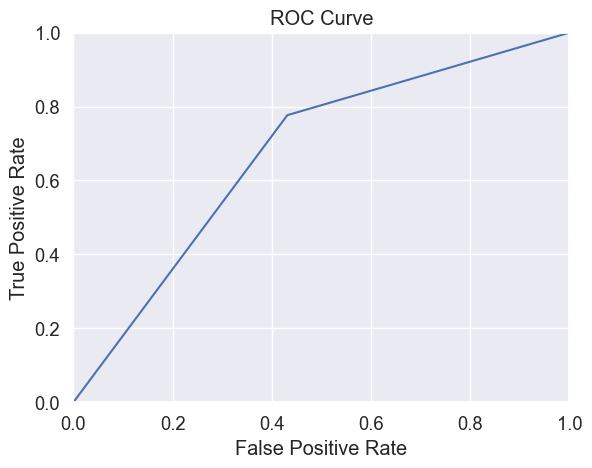

In [72]:
pred_proba = forest.predict_proba(X_test_reduce)

roc(y_test, pred_proba[:, 1])

Average Precision: 0.87


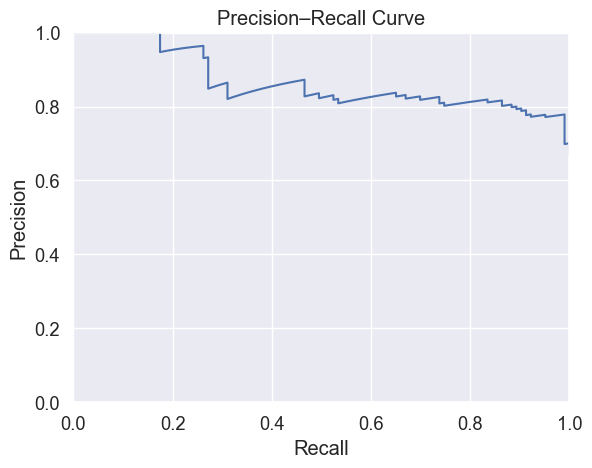

In [73]:
prc(y_test, pred_proba[:, 1])

In [74]:
oob_error = 1 - forest.oob_score_
print('Out-of-bag error: {}'.format(round(oob_error, 3)))

Out-of-bag error: 0.189
